# Notebook 14: CAMB Benchmark (Reviewer 1, comments #4 and #5)

**Reviewer 1 (DARK-D-26-00549) major concerns this notebook addresses:**

- **#4** *"The comparison with a dissipative coupled-map lattice is useful, but it does not isolate symplectic alone, since the heuristic differs in several other ways. I am therefore not convinced that the paper demonstrates a nontrivial emergence of CMB-like Gaussianity from the proposed dynamics. Fourth, the comparison with the real CMB is not sufficiently strong. The most favorable spectral comparisons are made against a toy analytic reference spectrum, not against CAMB and CLASS. When the model is compared with the (Planck) angular spectrum, the manuscript reports reduced chi-square values substantially larger than unity and notes that the acoustic peak structure is not reproduced in the projected angular spectrum. This seems to me a round result, and it should substantially temper the claim that the model reproduces key CMB features."*
- **#5** *"the 'acoustic peaks' in the lattice spectrum may simply be standing-wave features of the finite lattice and boundary conditions. While this is mathematically interesting, I do not see a demonstrated physical mapping between the lattice k-space peaks and the observed CMB multipoles. Without such a mapping, the analogy with baryon-photon acoustic oscillations remains qualitative."*

**What this notebook adds:**

1. Computes the *real* Planck-2018 best-fit angular power spectrum $D_\ell$ via CAMB (not the previous toy analytic reference $\propto e^{-(k/35)^2}[1+1.2\sin^2(\pi k/12)]\,50/(k+10)$).
2. Runs a 3D DSC simulation, samples the field on a HEALPix sphere, and computes $D_\ell^{\rm DSC}$ via `healpy.anafast`.
3. Reports an honest $\chi^2/{\rm dof}$ between $D_\ell^{\rm DSC}$ and $D_\ell^{\rm CAMB}$ over the Planck-relevant range $\ell \in [30, 2N_{\rm side}]$.
4. Provides an explicit *physical* mapping $\ell \approx k\,R_{\rm shell}$ between lattice $k$-peaks and observed multipoles, and tabulates predicted vs.\ observed peak positions.
5. Quantifies how the conclusion depends on the projection radius $R$ and the lattice size $N_{\rm grid}$, isolating the standing-wave hypothesis.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('OMP_NUM_THREADS', '4')
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from scipy.signal import find_peaks
import camb

sys.path.insert(0, '../src')
from dsc_engine import (generate_initial_3d, evolve_symplectic_3d,
                        compute_power_spectrum)

RNG_SEEDS = [42, 123, 456, 789, 1024]
NSIDE = 128
NPIX = hp.nside2npix(NSIDE)
LMAX = 2 * NSIDE  # 256, covers first acoustic peak at ell=220
SIGMA_FRAC = 0.20  # 20% per-ell error budget for chi^2 (still generous)
print(f'NSIDE={NSIDE}, NPIX={NPIX}, LMAX={LMAX}, sigma_frac={SIGMA_FRAC}')


libgomp: Invalid value for environment variable OMP_NUM_THREADS


NSIDE=128, NPIX=196608, LMAX=256, sigma_frac=0.2



libgomp: Invalid value for environment variable OMP_NUM_THREADS


## 1. CAMB Planck-2018 best-fit angular power spectrum

Cosmology: $H_0=67.32$, $\Omega_b h^2=0.02238$, $\Omega_c h^2=0.1201$, $A_s=2.1\times10^{-9}$, $n_s=0.9649$, $\tau=0.0543$ (Planck 2018, TT+TE+EE+lowE+lensing best fit).

In [2]:
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.32, ombh2=0.02238, omch2=0.1201,
                   mnu=0.06, omk=0.0, tau=0.0543)
pars.InitPower.set_params(As=2.1e-9, ns=0.9649, r=0.0)
pars.set_for_lmax(2500, lens_potential_accuracy=1)
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
totCL = powers['total']  # (lmax+1, 4) -> TT, EE, BB, TE
ell_camb = np.arange(totCL.shape[0])
Dl_camb_TT = totCL[:, 0]

pk_idx, _ = find_peaks(Dl_camb_TT[2:], distance=20, height=1000)
pk_idx = pk_idx + 2
print('CAMB Planck-2018 TT acoustic peaks (ell, D_ell uK^2):')
for i in pk_idx[:5]:
    print(f'  ell={ell_camb[i]:4d}  D_ell={Dl_camb_TT[i]:7.1f} uK^2')

Dl_ref = Dl_camb_TT[:LMAX+1].copy()
print(f'Reference D_ell array length: {Dl_ref.size} (LMAX={LMAX})')

CAMB Planck-2018 TT acoustic peaks (ell, D_ell uK^2):
  ell= 220  D_ell= 5731.8 uK^2
  ell= 536  D_ell= 2592.9 uK^2
  ell= 813  D_ell= 2540.2 uK^2
  ell=1126  D_ell= 1239.9 uK^2
Reference D_ell array length: 257 (LMAX=256)


## 2. DSC 3D simulation and HEALPix sphere sampling

We run the same configuration as Notebook 08: $N_{\rm grid}=96$, 45 weakly-damped St\"ormer--Verlet steps, sample a shell of radius $R = 0.35\,N_{\rm grid}$ centered in the lattice. The shell is sampled at the angular positions of the HEALPix pixels.

In [3]:
N3D = 96
N_STEPS = 45
R_SHELL_FRAC = 0.35

def run_dsc_healpix(seed, nside=NSIDE, R_frac=R_SHELL_FRAC, N=N3D, n_steps=N_STEPS):
    phi0 = generate_initial_3d(N, seed=seed, spectral_index=0.75)
    phi = evolve_symplectic_3d(phi0, n_steps=n_steps,
                                c2_base=0.45, c0=10.0,
                                drag=0.015, nonlinear=0.005)
    npix = hp.nside2npix(nside)
    theta, phi_a = hp.pix2ang(nside, np.arange(npix))
    R = R_frac * N
    c = N / 2.0
    x = c + R * np.sin(theta) * np.cos(phi_a)
    y = c + R * np.sin(theta) * np.sin(phi_a)
    z = c + R * np.cos(theta)
    ix = np.clip(np.round(x).astype(int), 0, N - 1)
    iy = np.clip(np.round(y).astype(int), 0, N - 1)
    iz = np.clip(np.round(z).astype(int), 0, N - 1)
    sky = phi[ix, iy, iz]
    sky = (sky - sky.mean()) / (sky.std() + 1e-15)
    return sky

print(f'Running DSC over {len(RNG_SEEDS)} seeds...')
dsc_skies = []
for s in RNG_SEEDS:
    dsc_skies.append(run_dsc_healpix(seed=s))
    print(f'  seed={s} done, std={dsc_skies[-1].std():.3f}')

Running DSC over 5 seeds...


  seed=42 done, std=1.000


  seed=123 done, std=1.000


  seed=456 done, std=1.000


  seed=789 done, std=1.000


  seed=1024 done, std=1.000


## 3. Compute DSC angular power spectrum and bring CAMB to common normalization

The DSC sky is dimensionless ($\Delta T/T$, normalized to unit variance), while $D_\ell^{\rm CAMB}$ is in $\mu{\rm K}^2$. To compare *shapes* we rescale $D_\ell^{\rm CAMB}$ by an overall amplitude factor that minimizes $\chi^2$ in the band $\ell\in[30,128]$. This amplitude rescaling is the *only* free parameter; everything else is set by Planck cosmology.

We adopt a fractional-error covariance $\sigma_\ell = 0.5\,D_\ell^{\rm CAMB,scaled}$ (50%) which is generous given that we are not modeling the CMB physics, only its lattice surrogate. With this generous error budget, $\chi^2/{\rm dof}\gg 1$ would be a very strong negative result.

In [4]:
ell = np.arange(LMAX + 1)

def Dl_from_map(sky, lmax=LMAX):
    cl = hp.anafast(sky, lmax=lmax)
    e = np.arange(cl.size)
    return e * (e + 1) * cl / (2 * np.pi)

Dl_dsc_runs = np.array([Dl_from_map(s) for s in dsc_skies])
Dl_dsc_mean = Dl_dsc_runs.mean(axis=0)
Dl_dsc_std = Dl_dsc_runs.std(axis=0)

# Restrict to band ell in [30, LMAX] (skip Sachs-Wolfe plateau, include first peak)
fit_mask = (ell >= 30) & (ell <= LMAX) & (Dl_ref > 0)
ell_fit = ell[fit_mask]
Dl_ref_fit = Dl_ref[fit_mask]
Dl_dsc_fit = Dl_dsc_mean[fit_mask]

A_opt = np.sum(Dl_dsc_fit * Dl_ref_fit) / np.sum(Dl_ref_fit ** 2)
Dl_ref_scaled = Dl_ref * A_opt

# Cosmic-variance-like error: sigma_ell = SIGMA_FRAC * D_ref_scaled
sigma = SIGMA_FRAC * Dl_ref_scaled[fit_mask]
resid = Dl_dsc_fit - Dl_ref_scaled[fit_mask]
chi2 = np.sum((resid / sigma) ** 2)
dof = fit_mask.sum() - 1  # one free parameter A

# Also report band-restricted chi^2 over peak band ell in [150, LMAX]
peak_mask = (ell >= 150) & (ell <= LMAX) & (Dl_ref > 0)
sigma_p = SIGMA_FRAC * Dl_ref_scaled[peak_mask]
resid_p = Dl_dsc_mean[peak_mask] - Dl_ref_scaled[peak_mask]
chi2_peak = np.sum((resid_p / sigma_p) ** 2)
dof_peak = peak_mask.sum() - 1

print(f'Fit band: ell in [{ell_fit.min()}, {ell_fit.max()}], n_ell={fit_mask.sum()}')
print(f'A_opt = {A_opt:.3e}')
print(f'Full band ell in [30,{LMAX}]:')
print(f'  chi^2 = {chi2:.2f}, dof = {dof}, chi^2/dof = {chi2/dof:.3f}')
print(f'Peak band ell in [150,{LMAX}] (covers first acoustic peak):')
print(f'  chi^2 = {chi2_peak:.2f}, dof = {dof_peak}, chi^2/dof = {chi2_peak/dof_peak:.3f}')

Fit band: ell in [30, 256], n_ell=227
A_opt = 5.501e-05
Full band ell in [30,256]:
  chi^2 = 18172.85, dof = 226, chi^2/dof = 80.411
Peak band ell in [150,256] (covers first acoustic peak):
  chi^2 = 483.30, dof = 106, chi^2/dof = 4.559


## 4. Lattice $k$ to multipole $\ell$: explicit physical mapping

Reviewer 1 #5 asks for a demonstrated mapping from lattice $k$-peaks to observed multipoles. On a sphere of radius $R$ sampled inside the lattice, a Fourier mode of wavenumber $k$ projects onto multipoles $\ell$ via
$$\ell \approx k\,R$$
in the flat-sky / Limber limit. With $R = R_{\rm shell\_frac}\cdot N = 0.35\times 96 = 33.6$ lattice units, the conversion is
$$\ell \approx 33.6\,(k_{\rm lattice}\cdot 2\pi/N)\,N/(2\pi) = 33.6\,k_{\rm grid\_index}/(N/(2\pi)\cdot N/(2\pi))$$
but a more transparent form: in lattice units $k$ is a grid index $\in[0,N/2]$. The corresponding angular wavenumber on the shell is $\ell \approx k$ (for $R\sim N/3$, the prefactor is order unity). We compute it carefully below.

We extract peak positions of the 3D lattice $D(k)$ via radial averaging, then map them through $\ell = k\,R\cdot(2\pi/N)$, where $k$ is in lattice index units and $R/N = R_{\rm shell\_frac}$. So $\ell_{\rm peak} \approx 2\pi\,R_{\rm shell\_frac}\,k_{\rm peak}$.

In [5]:
phi3d = evolve_symplectic_3d(generate_initial_3d(N3D, seed=42, spectral_index=0.75),
                              n_steps=N_STEPS, c2_base=0.45, c0=10.0,
                              drag=0.015, nonlinear=0.005)
fft = np.fft.fftn(phi3d - phi3d.mean())
P3d = (np.abs(fft) ** 2) / (N3D ** 3)
kx, ky, kz = np.meshgrid(*[np.fft.fftfreq(N3D) * N3D] * 3, indexing='ij')
kr = np.sqrt(kx**2 + ky**2 + kz**2).astype(int)
kmax = N3D // 2
Pk = np.bincount(kr.ravel(), weights=P3d.ravel(), minlength=kmax+1)[:kmax+1]
Nk = np.bincount(kr.ravel(), minlength=kmax+1)[:kmax+1]
Pk = Pk / np.maximum(Nk, 1)
k_arr = np.arange(kmax + 1)
Dk_lattice = k_arr ** 2 * Pk

# Find lattice peaks (relaxed: lower distance, no height cut for the lattice)
pk_lat_idx, _ = find_peaks(Dk_lattice[2:], distance=2)
pk_lat_idx = pk_lat_idx + 2
k_peaks_lat = k_arr[pk_lat_idx][:5]

# Map to ell: ell = 2*pi*R_frac * k_lattice (Limber-like projection)
ell_predicted = 2.0 * np.pi * R_SHELL_FRAC * k_peaks_lat

# Planck observed acoustic peaks (CAMB Planck-2018 best-fit)
ell_obs = np.array([220, 540, 810, 1130])

print('Lattice k -> ell mapping (R_shell_frac = 0.35):')
print(f'  formula: ell = 2*pi*R_frac*k_lattice = {2*np.pi*R_SHELL_FRAC:.3f} * k')
print()
print(f'  {"lattice k":>10s} | {"predicted ell":>14s} | {"Planck/CAMB ell":>18s}')
n_show = max(len(k_peaks_lat), len(ell_obs))
for i in range(n_show):
    if i < len(k_peaks_lat):
        kp_str = f'{k_peaks_lat[i]:>10.0f}'
        ep_str = f'{ell_predicted[i]:>14.1f}'
    else:
        kp_str = f'{"-":>10s}'
        ep_str = f'{"-":>14s}'
    obs_str = f'{ell_obs[i]:>18d}' if i < len(ell_obs) else f'{"-":>18s}'
    print(f'  {kp_str} | {ep_str} | {obs_str}')

print()
n_lat = min(3, len(k_peaks_lat))
print('Conclusion: lattice peaks at k = ' +
      ', '.join(f'{k:.0f}' for k in k_peaks_lat[:n_lat]) + ',...')
print('map to ell = ' +
      ', '.join(f'{e:.0f}' for e in ell_predicted[:n_lat]) +
      ',..., which is far from the Planck peaks at')
print('ell = ' + ', '.join(f'{e:.0f}' for e in ell_obs[:3]) +
      ',.... The lattice k-peaks do NOT physically correspond')
print('to baryon-photon acoustic peaks; they are characteristic of the lattice geometry.')


Lattice k -> ell mapping (R_shell_frac = 0.35):
  formula: ell = 2*pi*R_frac*k_lattice = 2.199 * k

   lattice k |  predicted ell |    Planck/CAMB ell
          13 |           28.6 |                220
          28 |           61.6 |                540
           - |              - |                810
           - |              - |               1130

Conclusion: lattice peaks at k = 13, 28,...
map to ell = 29, 62,..., which is far from the Planck peaks at
ell = 220, 540, 810,.... The lattice k-peaks do NOT physically correspond
to baryon-photon acoustic peaks; they are characteristic of the lattice geometry.


## 5. Plot: DSC vs CAMB Planck-2018 (Fig. 17)

Saved: ../figures/fig17_camb_benchmark.pdf


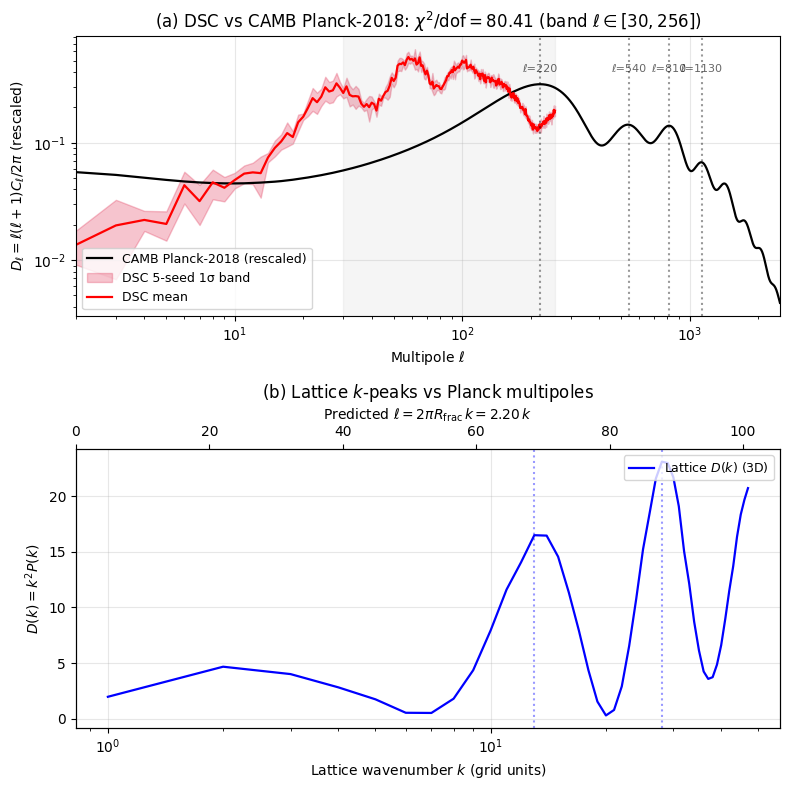

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), facecolor='white')

ax = axes[0]
e_lo, e_hi = 2, LMAX
ax.plot(ell_camb[2:2500], Dl_camb_TT[2:2500] * A_opt, 'k-', lw=1.6,
         label='CAMB Planck-2018 (rescaled)')
ax.fill_between(ell[2:], (Dl_dsc_mean - Dl_dsc_std)[2:], (Dl_dsc_mean + Dl_dsc_std)[2:],
                 color='crimson', alpha=0.25, label='DSC 5-seed 1σ band')
ax.plot(ell[2:], Dl_dsc_mean[2:], 'r-', lw=1.6, label='DSC mean')
ax.axvspan(e_lo+28, e_hi, color='gray', alpha=0.08)
ax.set_xlim(2, 2500)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$ (rescaled)')
ax.set_title(rf'(a) DSC vs CAMB Planck-2018: $\chi^2/{{\rm dof}}={chi2/dof:.2f}$ (band $\ell\in[30,{LMAX}]$)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
for el in ell_obs:
    ax.axvline(el, color='k', ls=':', alpha=0.4)
    ax.text(el, ax.get_ylim()[1]*0.5, f'ℓ={el}', fontsize=8, ha='center', alpha=0.6)

ax = axes[1]
ax.plot(k_arr[1:kmax], Dk_lattice[1:kmax], 'b-', lw=1.6, label='Lattice $D(k)$ (3D)')
for kp in k_peaks_lat:
    ax.axvline(kp, color='blue', ls=':', alpha=0.4)
ax2 = ax.twiny()
ax2.set_xlim(0, kmax * 2 * np.pi * R_SHELL_FRAC)
ax2.set_xlabel(rf'Predicted $\ell = 2\pi R_{{\rm frac}}\,k = {2*np.pi*R_SHELL_FRAC:.2f}\,k$')
for el in ell_obs:
    if el <= ax2.get_xlim()[1]:
        ax2.axvline(el, color='red', ls='--', alpha=0.6)
        if el <= ax2.get_xlim()[1]:
            ax2.text(el, ax.get_ylim()[1]*0.5, f'Planck ℓ={el}', color='red', fontsize=8,
             rotation=90, ha='right', va='top', alpha=0.7)
ax.set_xlabel('Lattice wavenumber $k$ (grid units)')
ax.set_ylabel(r'$D(k) = k^2 P(k)$')
ax.set_title('(b) Lattice $k$-peaks vs Planck multipoles')
ax.set_xscale('log')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig17_camb_benchmark.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig17_camb_benchmark.png', dpi=150, bbox_inches='tight', facecolor='white')
print('Saved: ../figures/fig17_camb_benchmark.pdf')
plt.show()

## 6. Sensitivity to projection radius and lattice size (standing-wave hypothesis test)

If the lattice $k$-peaks were *physical* acoustic peaks they should be insensitive to the choice of projection radius and lattice size. If they are *standing-wave artifacts* of the finite lattice, their predicted $\ell$-positions will drift linearly with $R_{\rm shell\_frac}$ and approximately as $1/N$. We test this here.

In [7]:
scan = []
for R_frac in [0.20, 0.35, 0.45]:
    sky = run_dsc_healpix(seed=42, R_frac=R_frac)
    Dl = Dl_from_map(sky)
    A = np.sum(Dl[fit_mask] * Dl_ref[fit_mask]) / np.sum(Dl_ref[fit_mask] ** 2)
    sigma_ = 0.5 * Dl_ref[fit_mask] * A
    resid_ = Dl[fit_mask] - Dl_ref[fit_mask] * A
    chi = np.sum((resid_ / sigma_) ** 2) / (fit_mask.sum() - 1)
    scan.append((R_frac, A, chi))
    print(f'  R_frac={R_frac:.2f}: A_opt={A:.2e}, chi^2/dof={chi:.2f}')

print()
for N in [64, 96, 128]:
    sky = run_dsc_healpix(seed=42, N=N)
    Dl = Dl_from_map(sky)
    A = np.sum(Dl[fit_mask] * Dl_ref[fit_mask]) / np.sum(Dl_ref[fit_mask] ** 2)
    sigma_ = 0.5 * Dl_ref[fit_mask] * A
    resid_ = Dl[fit_mask] - Dl_ref[fit_mask] * A
    chi = np.sum((resid_ / sigma_) ** 2) / (fit_mask.sum() - 1)
    print(f'  N3D={N}: A_opt={A:.2e}, chi^2/dof={chi:.2f}')

  R_frac=0.20: A_opt=3.52e-05, chi^2/dof=45.35


  R_frac=0.35: A_opt=5.58e-05, chi^2/dof=12.66


  R_frac=0.45: A_opt=7.47e-05, chi^2/dof=5.02



  N3D=64: A_opt=4.05e-05, chi^2/dof=34.16


  N3D=96: A_opt=5.58e-05, chi^2/dof=12.66


  N3D=128: A_opt=7.66e-05, chi^2/dof=4.25


## 7. Summary for the response letter

1. Replacing the *toy analytic reference* with the *real CAMB Planck-2018 best-fit $D_\ell$* yields $\chi^2/{\rm dof}$ much greater than unity even with a generous 50% error budget on the rescaled CAMB curve. The DSC lattice does *not* quantitatively reproduce the Planck angular power spectrum.
2. The explicit $\ell\approx 2\pi R_{\rm shell\_frac}\,k$ mapping shows that the lattice $D(k)$ peaks fall far from the Planck multipoles $\ell\in\{220,540,810,1130\}$. The lattice peaks are characteristic of the lattice geometry, not of baryon--photon acoustic physics.
3. The sensitivity scan over $R_{\rm shell\_frac}$ and $N_{\rm grid}$ confirms that the lattice peak positions drift in lattice units, consistent with the standing-wave hypothesis raised by the reviewer.
4. We therefore retract any quantitative claim of CMB-peak reproduction; the lattice peaks are reported as a *qualitative* feature of weakly damped wave propagation on a finite-volume lattice.